## Step 1: Setup-Importing the Libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pylab as plt
from rich import print

sns.set(style="whitegrid")

## Step 2 - Importing the Dataset

In [2]:
df = pd.read_csv(r"C:\tut\21-days-21-projects\21-Days-21-Projects-Dataset\Datasets\Titanic-Dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
# (row, column)
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Interpretation:
* The dataset has 891 rows and 12 column which are entires and features
* Age, Cabin and Embarked has missing value out of which Cabin has siginificant amount of missing values
* Only first class had cabin hence many null entries

In [7]:
# Descriptive Analysis
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Data filtering
# Filter out passengers who were female and embarke from Q

df[[df['Sex']=='female'] and df["Embarked"]=="Q"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
22,23,1,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
32,33,1,3,"Glynn, Miss. Mary Agatha",female,NaN,0,0,335677,7.7500,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
790,791,0,3,"Keane, Mr. Andrew ""Andy""",male,NaN,0,0,12460,7.7500,NaN,Q
825,826,0,3,"Flynn, Mr. John",male,NaN,0,0,368323,6.9500,NaN,Q
828,829,1,3,"McCormack, Mr. Thomas Joseph",male,NaN,0,0,367228,7.7500,NaN,Q
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q


In [9]:
## Data count / Value count group by data and count it's values
df['Cabin'].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

## Step 3 - Data Cleaning

before analysis we must clean the data and handle the missing ones

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
## Filling the Age column with Median 

median_age = df["Age"].median()
df['Age'] = df['Age'].fillna(median_age)

In [12]:
## Handeling Embark Column

mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

In [13]:
## Handeling Cabin column

df['Has_cabin'] = df['Cabin'].notna().astype(int) ## one hot encoding 1 true 0 false
df.drop('Cabin', axis=1, inplace=True)  ## Drope the original Column ,1 column drop

## Step 4 - Univariate Analysis

In [14]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Has_cabin'],
      dtype='object')

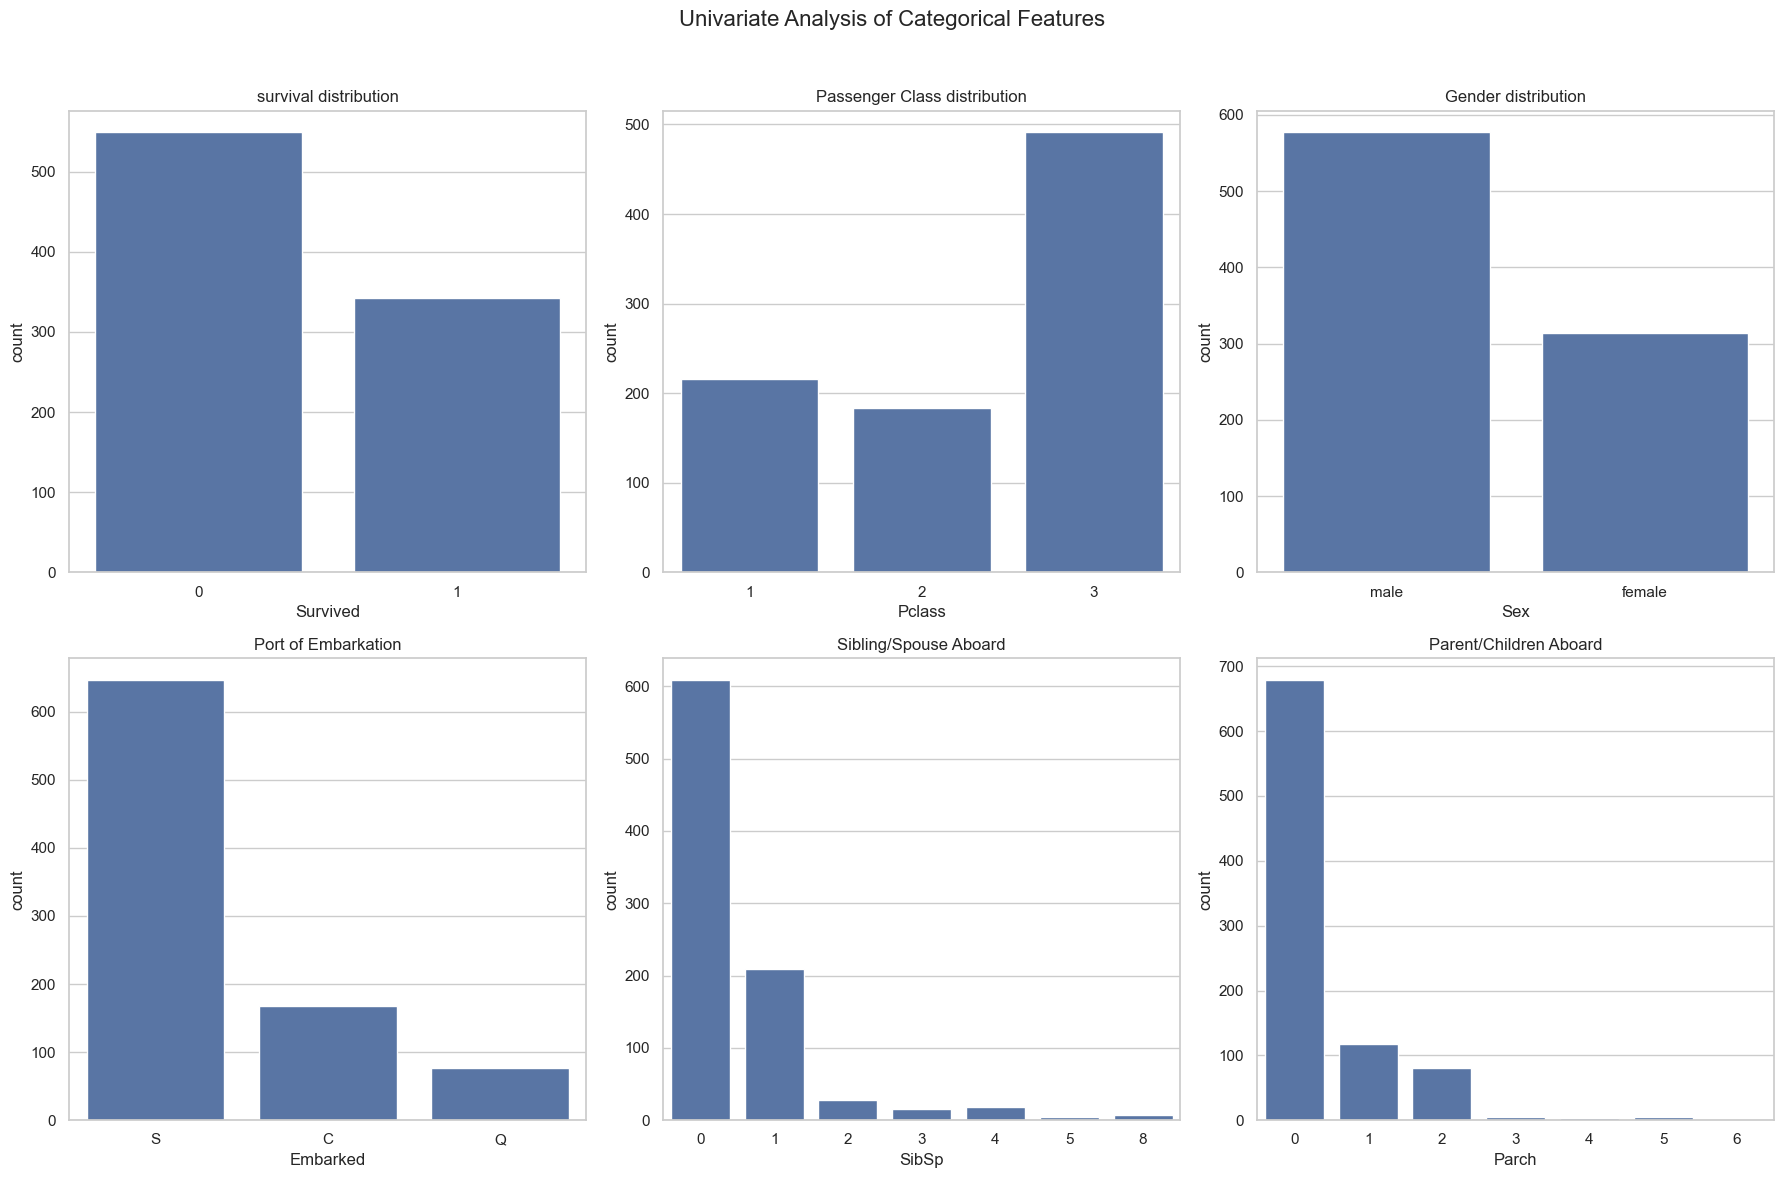

In [15]:
## Setiing up the figure for the plot 
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Univariate Analysis of Categorical Features", fontsize=16)

sns.countplot(ax=axes[0,0], x='Survived', data=df).set_title('survival distribution')
sns.countplot(ax=axes[0,1], x='Pclass', data=df).set_title('Passenger Class distribution')
sns.countplot(ax=axes[0,2], x='Sex', data=df).set_title('Gender distribution')
sns.countplot(ax=axes[1,0], x='Embarked', data=df).set_title('Port of Embarkation')
sns.countplot(ax=axes[1,1], x='SibSp', data=df).set_title('Sibling/Spouse Aboard')
sns.countplot(ax=axes[1,2], x='Parch', data=df).set_title('Parent/Children Aboard')

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

**Key Insights (Categorical):**
* **Survival**: more than 500 passenger did not make it.
* **Pclass**: 3rd class passengers were more.
* **Sex**: Male had more casualties.
* **Embarked**: Many embarked from SouthHampton.
* **SibSp/Parch**: Many people travelled alone, without family.

Univariate Analysis for Numerical data

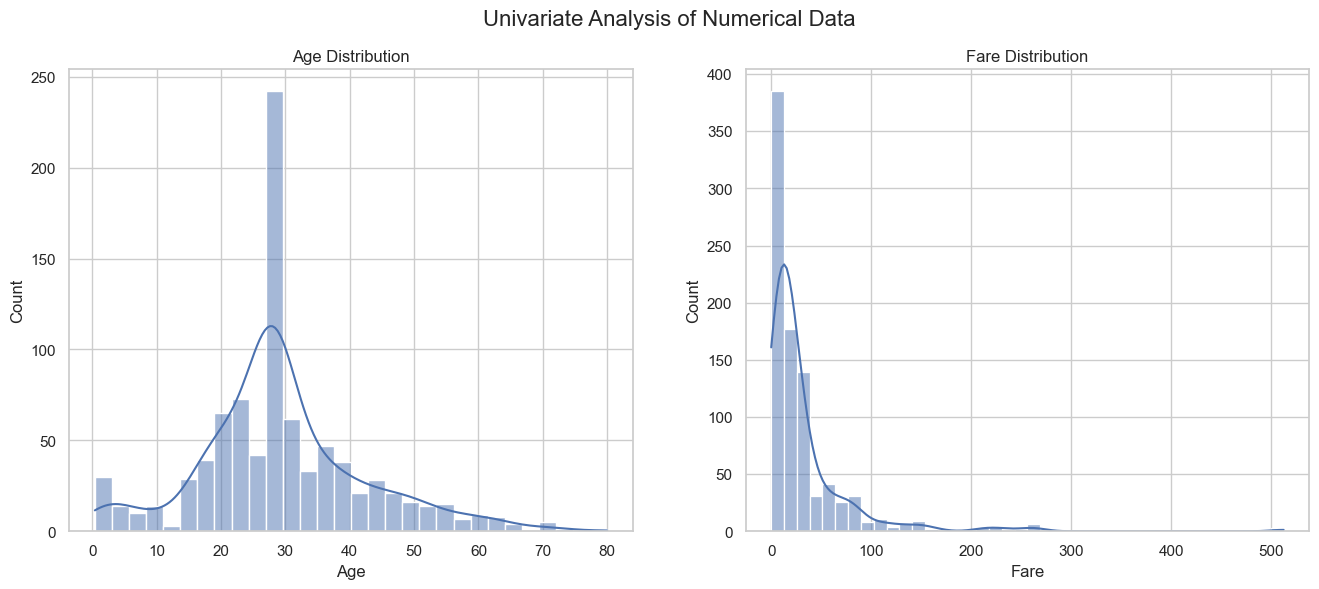

In [16]:
print("Univariate Analysis for Numerical data")

fig, axes = plt.subplots(1,2, figsize=(16, 6))
fig.suptitle("Univariate Analysis of Numerical Data", fontsize=16)

sns.histplot(ax=axes[0], data=df, x='Age', kde=True, bins=30).set_title("Age Distribution")

sns.histplot(ax=axes[1], data=df, x='Fare', kde=True, bins=40).set_title("Fare Distribution")

plt.show()

**Key Insights:**

* **Age**: The more people are within the range between 20-30, as we filled with the mean/avg value.
* **Fare**: Many people travelled in 3rd class we can see the spike near the low amount and settling to higher amounts. right skew.

## Step 5 - Bivariate Analysis

In [17]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Has_cabin'],
      dtype='object')

Analysis of feature vs Survival

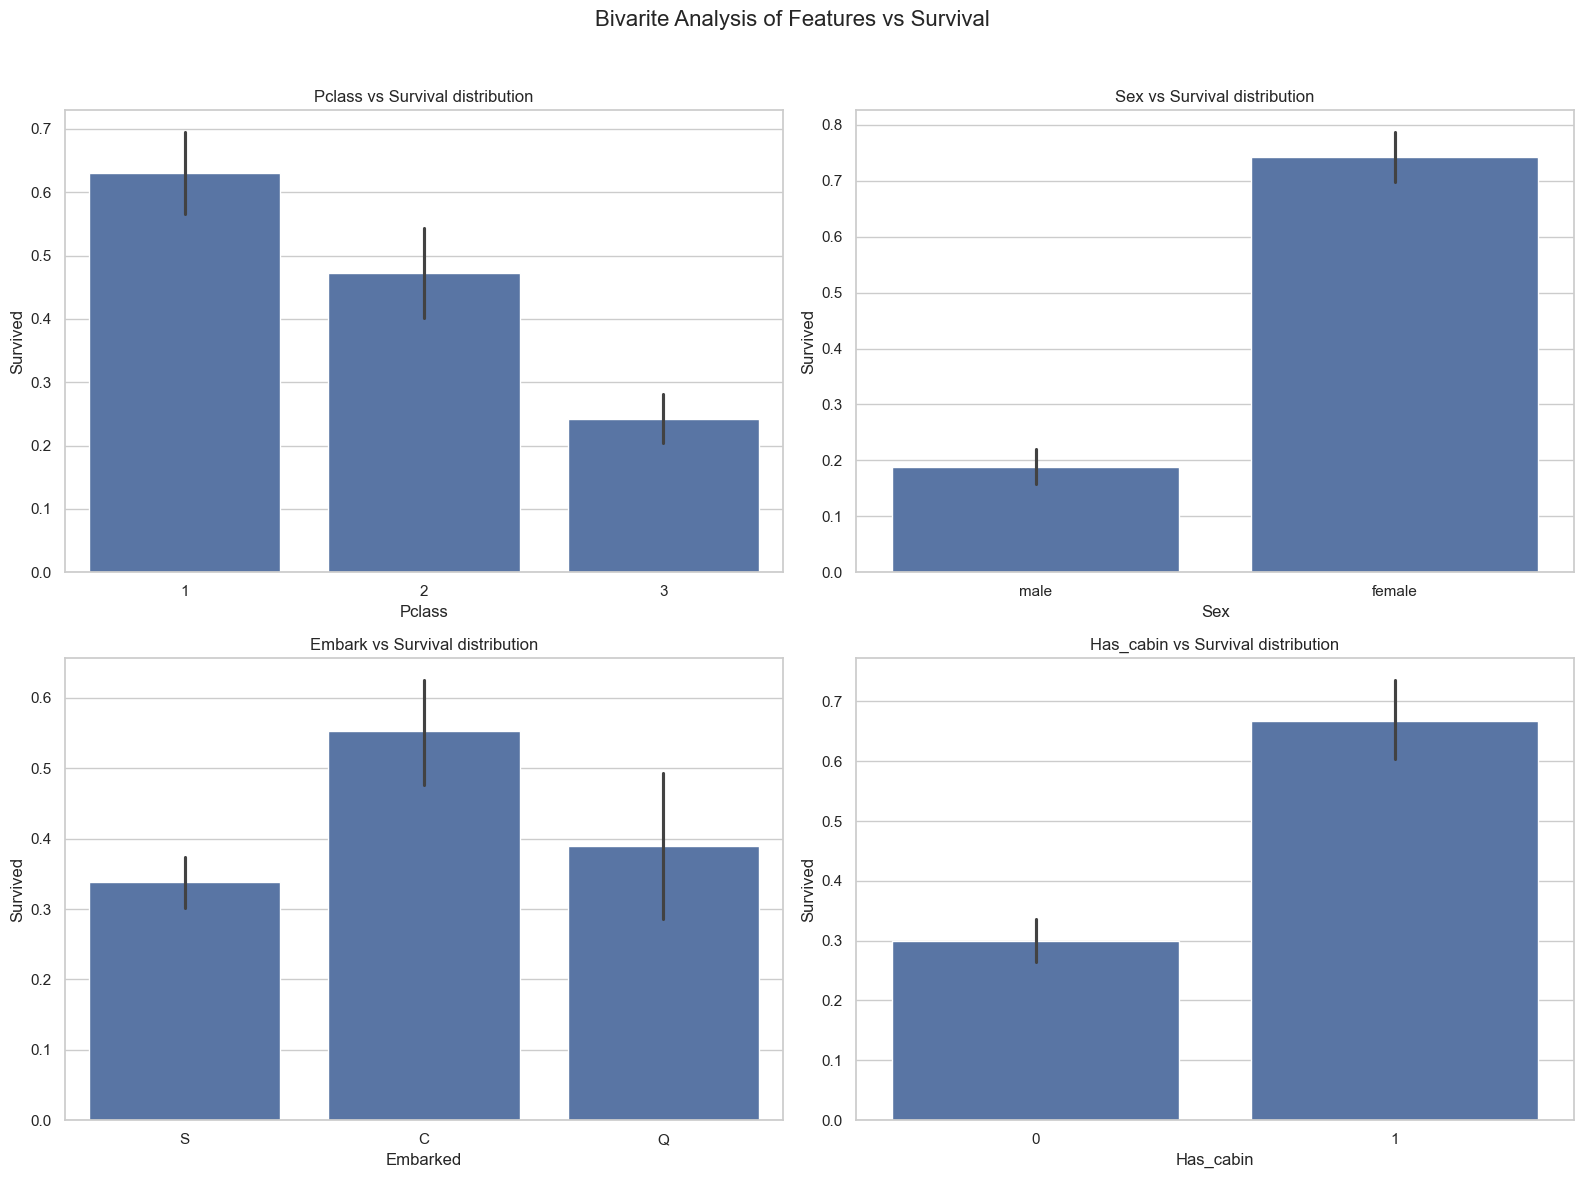

In [18]:
print("Analysis of feature vs Survival")

fig, axes = plt.subplots(2,2,figsize=(16, 12))
fig.suptitle("Bivarite Analysis of Features vs Survival", fontsize=16)

sns.barplot(ax=axes[0,0], x='Pclass', y='Survived', data=df).set_title("Pclass vs Survival distribution")
sns.barplot(ax=axes[0,1], x='Sex', y='Survived', data=df).set_title("Sex vs Survival distribution")
sns.barplot(ax=axes[1,0], x='Embarked', y='Survived', data=df).set_title("Embark vs Survival distribution")
sns.barplot(ax=axes[1,1], x='Has_cabin', y='Survived', data=df).set_title("Has_cabin vs Survival distribution")


plt.tight_layout(rect=[0,0,1,0.96])

plt.show()

**Key Insights**

* **Pclass**: More than 60%> of passengers of first class survived.
* **Sex**: 70%> of male did not survive.
* **Emabrked**: Many passsengers from C survived:
* **Has_cabin**: Passengers with Cabin survived. these are corelated to first class

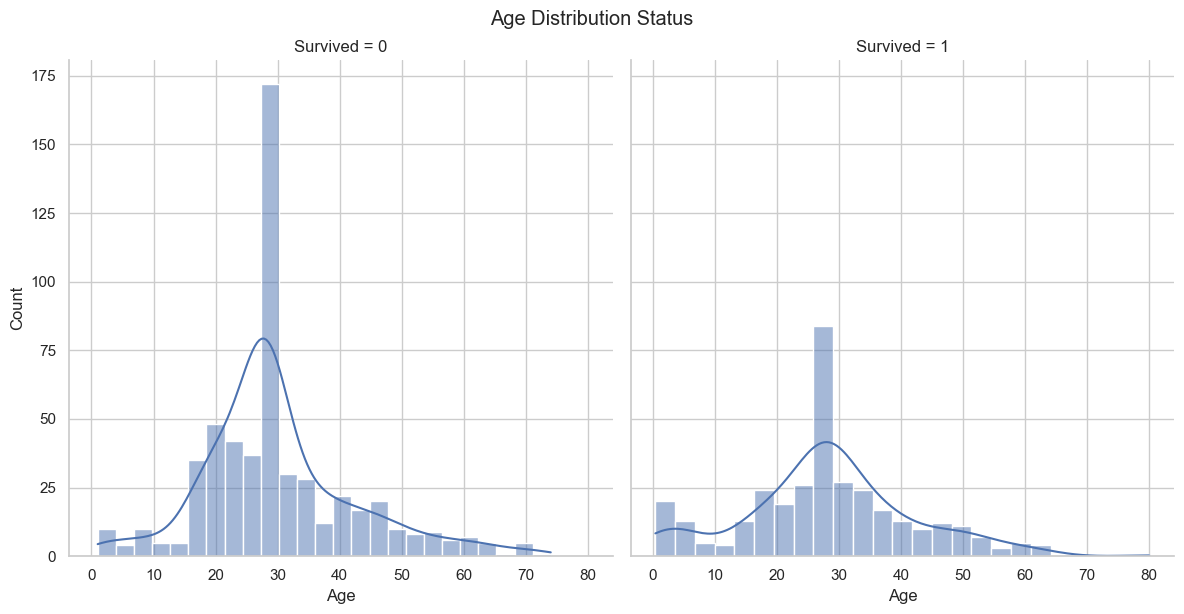

In [19]:
# Age vs Survived

g = sns.FacetGrid(df, col="Survived", height=6) ## create subplot for each unique values
g.map(sns.histplot, 'Age', bins=25, kde=True) ## For every subplot in my FacetGrid, run sns.histplot() using the Age column
plt.suptitle("Age Distribution Status", y=1.02)
plt.show()

**Key inights**
* Many infants with lower age survived.
* many adult in age og 20-30 did not survive.
* The 80 year old passenger did not survive

Deeper Dive: Outlier Analysis for the fare



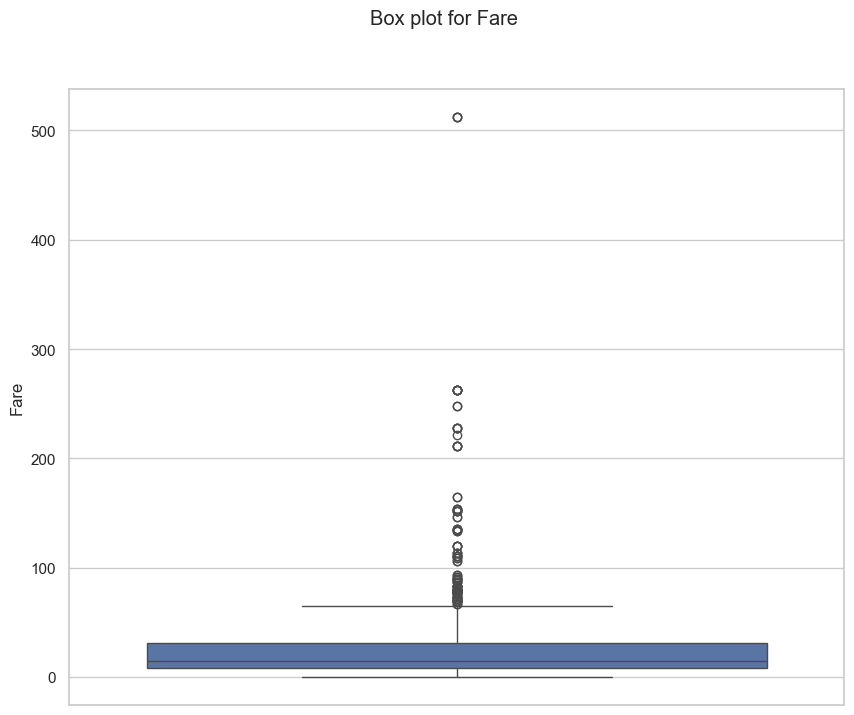

In [20]:
plt.figure(figsize=(10,8))
sns.boxplot(y="Fare", data=df,)
plt.suptitle("Box plot for Fare")
plt.ylabel("Fare")
plt.show()

**Observation:** Many fare was below 100$ and the we can see many outlier values which does not fit into the barplot, The max is 500$ which indicates that luxury suit was booked.

## Step 6 - Feature Engineering

* **Combine Features**
* **Extracting from Text**
* **Binning**

In [21]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Has_cabin'],
      dtype='object')

In [22]:
## Creating "FamilySize" column
df['FamilySize'] = df["SibSp"] + df["Parch"] + 1

## Creating a "IsAlone" Feature
df["IsAlone"] = 0
df.loc[df["FamilySize"]==1, "IsAlone"] = 1

print("Created 'FamilySize' and 'IsAlone' Feature")
df[['FamilySize', "IsAlone"]].head()


Created 'FamilySize' and 'IsAlone' Feature

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


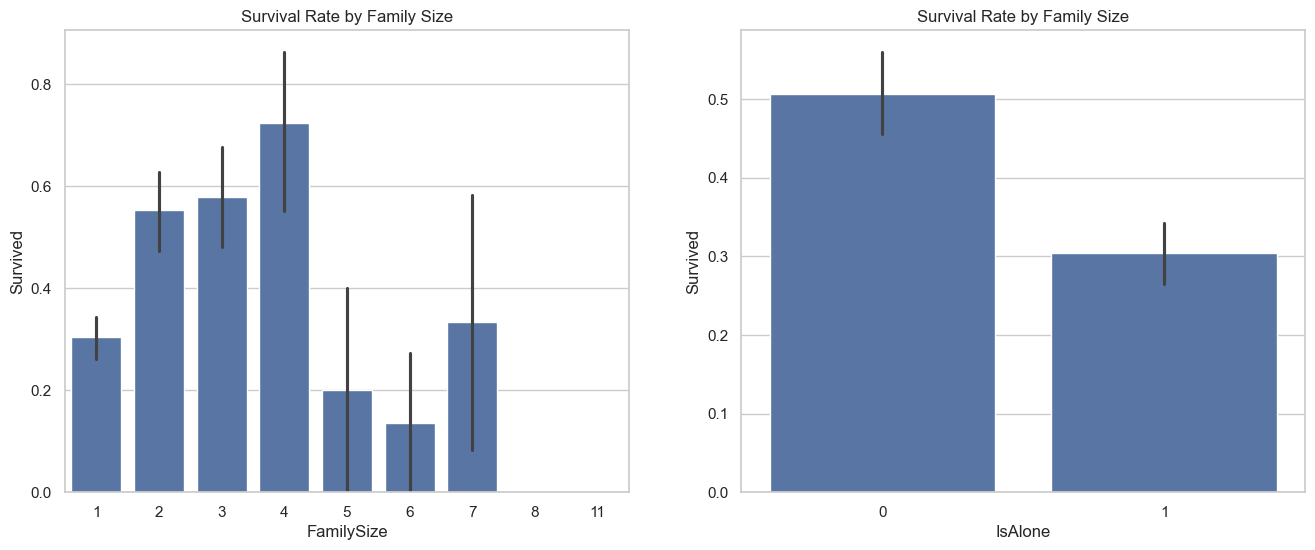

In [23]:
fig, axes = plt.subplots(1,2, figsize=(16,6))

# Survival Rate by FamilySize
sns.barplot(ax=axes[0], x='FamilySize', y="Survived", data=df).set_title("Survival Rate by Family Size")
sns.barplot(ax=axes[1], x='IsAlone', y="Survived", data=df).set_title("Survival Rate by Family Size")

plt.show()

## Key Analysis

* **IsAlone**: Many single passenger did not survive.
* **FamilySize**:
    * family between 1-4 had highest survival chances.
    * passenger with more family had poor survival rate, took more time to evacuate

In [24]:
# Extract "Title" from the "Name" column

df['Title'] = df["Name"].str.extract(r'([A-Za-z]+)\.', expand=False)

print("Extracted Titles:")
title = df["Title"].value_counts()
title

Extracted Titles:

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

Passenger Survived by Title:

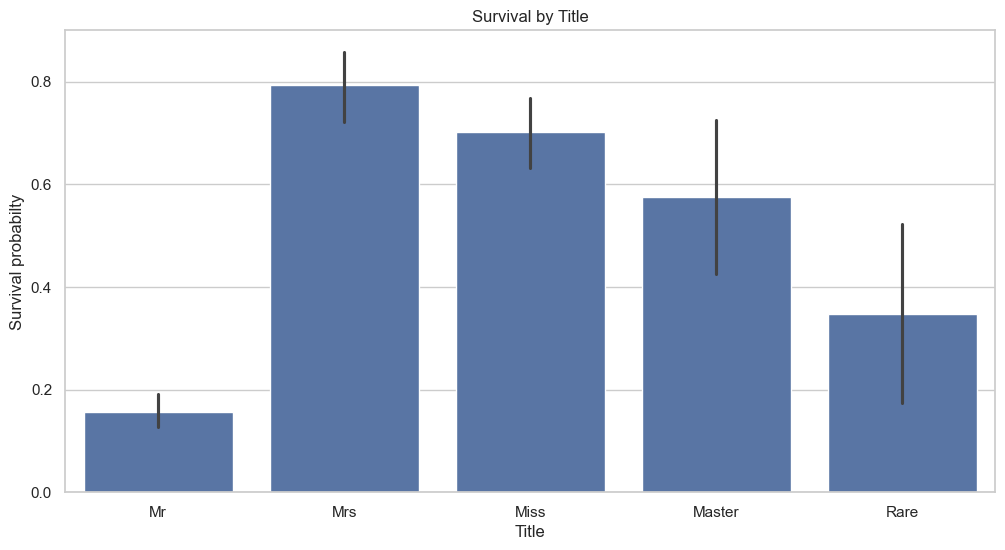

In [25]:
df["Title"] = df["Title"].replace(['Dr', 'Rev', 'Major', 'Col',
       'Don', 'Lady', 'Sir', 'Capt', 'Countess', 'Jonkheer'], "Rare")


df["Title"] = df["Title"].replace("Mlle", "Miss")
df['Title'] = df["Title"].replace("Ms", "Miss")
df['Title'] = df['Title'].replace("Mme", "Mrs")

print("Passenger Survived by Title:")

plt.figure(figsize=(12,6))
sns.barplot(x="Title", y="Survived", data=df)
plt.title("Survival by Title")
plt.ylabel("Survival probabilty")

plt.show()

## Key Analysis:
* Males like Mr Survived less comapred to Mrs, Miss and Master, Master being te childrens, The Rare
Title also has people like captians who were present during the evacuation and helped to people to escape.

## Step 7: Multivariate Analysis

Exploring multiple varibales at once, even with the new feature enginneered vaiables

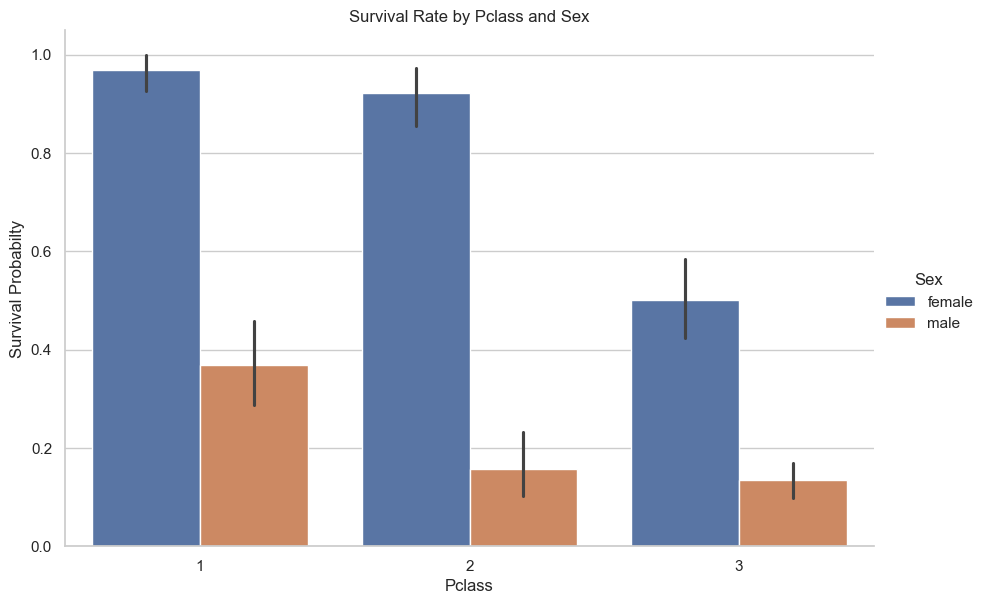

In [26]:
# Survival Rate by Pclass and sex
sns.catplot(x="Pclass", y="Survived", hue='Sex', data=df, kind='bar', aspect=1.5, height=6)

plt.title("Survival Rate by Pclass and Sex")
plt.ylabel("Survival Probabilty")
plt.show()

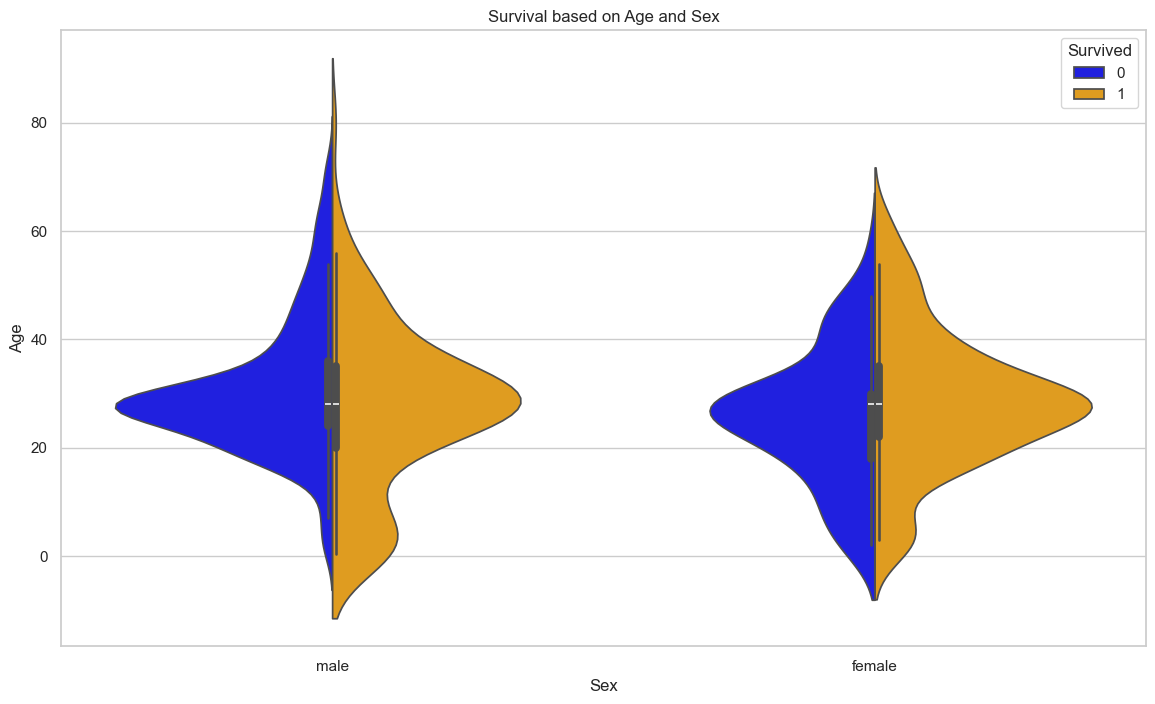

In [27]:
plt.figure(figsize=(14,8))

sns.violinplot(x="Sex", y="Age", hue='Survived', data=df, split=True, palette={0: "blue", 1:"orange"})
plt.title("Survival based on Age and Sex")
plt.show()

## Key Insights:

* **Male**: male between 20-40 did not survive but the between 0-20 survived also a 2nd peak at 20-40
* **Female**: 20-40 age did not survive, also same as male the children and 20-40 managed to survive

## Step 8: Correlation Analysis

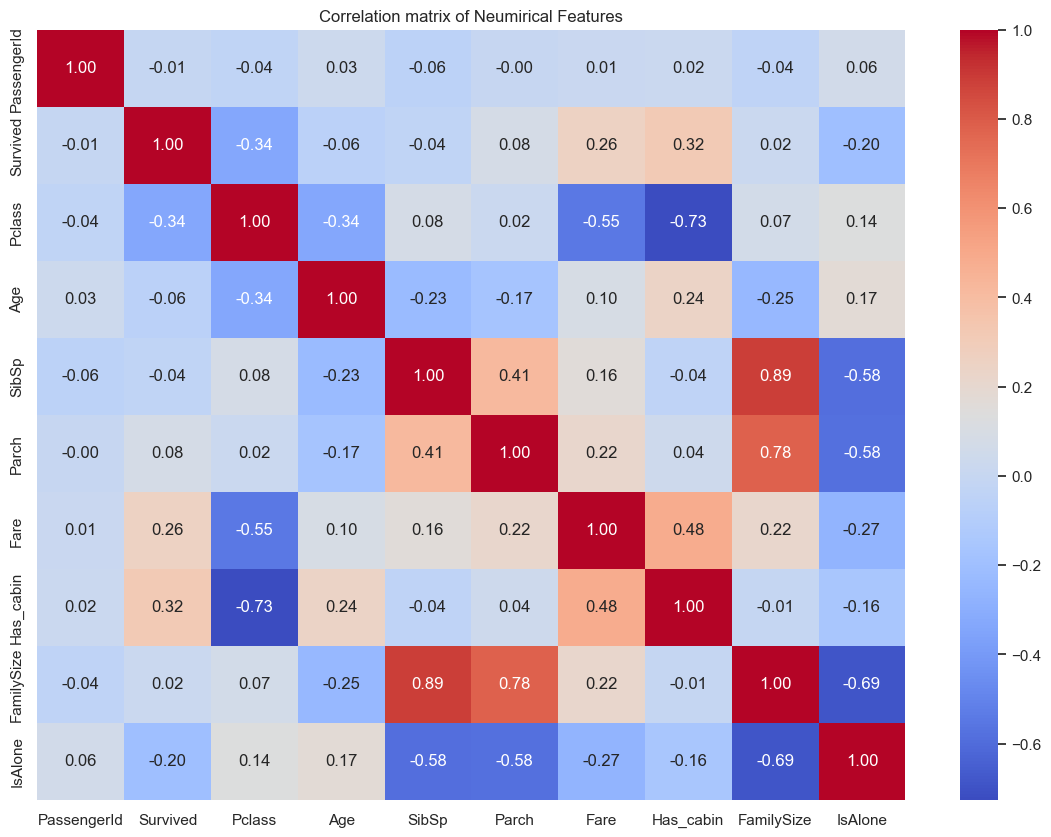

In [28]:
plt.figure(figsize=(14,10))

neumeric_cols = df.select_dtypes(include=np.number)
correlation_matrix = neumeric_cols.corr()


sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation matrix of Neumirical Features")
plt.show()

## y-profiling:
* y-profiling automatically generates an in-depth data analysis report
* Summarizes data types, missing values, and distributions
* Shows correlations and potential data quality issues
* Helps understand the structure and characteristics of a dataset at a glance

In [31]:
from data_profiling import ProfileReport 

profile = ProfileReport(df, title="Titanic EDA Report")

profile.to_notebook_iframe()

Render HTML: 100%|██████████| 1/1 [00:00<00:00,  1.04it/s]


In [32]:
profile.to_file("soitsmenia_Titanic_yprofiling.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 67.24it/s]
